# Linear Regression with Neural Networks
**Student:** Daniel Sozoranga

**Course:** Machine Learning

**Assignment:** Recovery (extra credit)

## Objective
Predict the **annual medical insurance cost** from personal features (age, BMI, children, smoker, region, sex) using **neural networks** with TensorFlow/Keras.

Three **models of the same problem** are trained to compare learning states:
1. **Well-trained** — correct bias/variance balance, with Dropout.
2. **Under-trained (underfitting)** — the model cannot learn the signal.
3. **Over-trained (overfitting)** — the model memorizes the train set and fails on test.

## Short theoretical framework
**Regression** predicts a continuous numeric value. A neural network performs regression when its output layer has **a single neuron with linear activation**. Without hidden layers it reduces to classical linear regression; with non-linear hidden layers it can learn non-linear relationships.

### Cake analogy
- **Features (ingredients):** age, BMI, smoker, etc.
- **Parameters (recipe):** the weights the network adjusts at every epoch.
- **Epochs:** each full pass over the data.
- **Underfitting:** recipe too simple, cake raw.
- **Overfitting:** we memorized THAT particular cake, cannot bake another one.
- **Well-trained:** a generalizable recipe — the cake turns out well every time.


## 1. Imports


**Libraries.** `numpy` / `pandas` for numerical and tabular data handling, `matplotlib` for plots, `tensorflow/keras` to build and train the neural networks, and `sklearn` utilities for train/test splitting, scaling, metrics, cross-validation and interpretability. A seed (42) is fixed so that results are reproducible across runs.


In [1]:
# Suppress TensorFlow retracing warnings and info logs for cleaner notebook output.
# These warnings do not indicate errors; they just clutter the output during K-fold CV.
import warnings, os
warnings.filterwarnings('ignore')                  # Silence Python-level warnings (deprecations, etc.)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'           # 0=all, 1=no INFO, 2=no WARNING, 3=only ERROR

# Core scientific stack
import numpy as np                                 # Numerical arrays and vectorized math
import pandas as pd                                # Tabular data handling (DataFrame, read_csv, etc.)
import matplotlib.pyplot as plt                    # Plotting library for loss curves, residuals, etc.

# Deep learning framework
import tensorflow as tf                            # TensorFlow backend
from tensorflow import keras                       # High-level Keras API for building models
from tensorflow.keras import layers, regularizers  # Layer primitives (Dense, Dropout, ...) and L1/L2 regularizers
tf.get_logger().setLevel('ERROR')                  # Silence the TF Python-side logger as well

# Classic ML utilities from scikit-learn
from sklearn.model_selection import train_test_split, KFold, learning_curve, validation_curve
# train_test_split: random train/test partition
# KFold: K-fold cross-validation splitter
# learning_curve / validation_curve: diagnostic curves for bias/variance

from sklearn.preprocessing import StandardScaler   # Mean-0 / std-1 feature scaler
from sklearn.linear_model import LinearRegression  # Classical OLS linear regression (baseline)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# MSE: mean squared error; MAE: mean absolute error; R2: coefficient of determination

from sklearn.inspection import permutation_importance   # Model-agnostic feature importance
from sklearn.base import BaseEstimator, RegressorMixin  # Base classes to wrap Keras as sklearn regressor

# Reproducibility: fix seeds so that results are stable across runs.
# NOTE: TF is not 100% deterministic on GPU, but with seeds + CPU it is very close.
np.random.seed(42); tf.random.set_seed(42)


## 2. Dataset loading


**Dataset.** The well-known US medical insurance dataset is loaded (1,338 records). The target `charges` is numeric and continuous → **regression** problem. Features: age, sex, BMI, number of children, smoker/non-smoker and region.


In [2]:
# Public insurance dataset from the R "Machine Learning with R" book repository.
# 1,338 rows, 7 columns. Target `charges` is a continuous variable (USD) -> regression problem.
URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(URL)                              # Download and parse the CSV into a DataFrame
print("Dimensions:", df.shape)                     # Expected: (1338, 7)
df.head()                                          # Preview the first 5 rows to confirm columns


Dimensions: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Descriptive statistics.** Useful to detect very different scales across variables (age 18–64 vs charges 1k–64k). This justifies standardizing the features and transforming the target to correct its skewness.


In [3]:
# Descriptive statistics per numerical column.
# Useful to check the scale disparity: `age` spans 18-64 while `charges` spans ~1k-64k USD.
# This scale gap justifies standardizing features and transforming the target.
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Preprocessing
One-hot encoding of categoricals, 80/20 split and standardization. `log1p` applied to the target to correct its skewness.


**Preprocessing.** Categorical variables are encoded with *one-hot encoding* (`drop_first=True` avoids perfect multicollinearity). The data is split 80% train / 20% test randomly with a fixed seed. `StandardScaler` (mean 0, standard deviation 1) is applied to the features — the scaler is fit **only** on the training set to avoid *data leakage*. `log1p` is applied to the target because `charges` has strong positive skew: the logarithmic transform makes the distribution more symmetric and stabilizes the network's training.


In [4]:
# --- One-hot encode the categorical columns ---
# `drop_first=True` drops one dummy level per category to avoid perfect multicollinearity
# (the dummy-variable trap). `astype(float)` ensures the booleans become 0.0/1.0 numerics.
df_enc = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True).astype(float)

# --- Split features and target ---
X = df_enc.drop('charges', axis=1).values          # Feature matrix as numpy array (shape: N x D)
y = df_enc['charges'].values                       # Target vector in original USD scale
feat_names = df_enc.drop('charges', axis=1).columns.tolist()  # Keep feature names for later (importance plot)

# --- Log-transform the target ---
# `charges` is right-skewed (long tail of high medical costs). log1p(y) = log(1 + y)
# symmetrizes the distribution and stabilizes gradients during NN training.
# We keep both `y` (original USD) and `y_log` because the OVER model will train on raw USD later.
y_log = np.log1p(y)

# --- Train/test split (80/20) ---
# random_state=42 makes the split reproducible. We carry both log and raw targets so every
# model can choose the scale it trains on, while evaluation is always against raw USD `y_te`.
X_tr, X_te, y_tr_log, y_te_log, y_tr, y_te = train_test_split(
    X, y_log, y, test_size=0.2, random_state=42)

# --- Standardize features ---
# IMPORTANT: fit the scaler ONLY on training data, then reuse it to transform test data.
# Fitting on the full dataset would leak test-set statistics into training (data leakage).
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)                # Learn mean/std from train, then transform
X_te_s = scaler.transform(X_te)                    # Apply the same transformation to test

print("Train:", X_tr_s.shape, " Test:", X_te_s.shape)


Train: (1070, 8)  Test: (268, 8)


## 4. Loss function and metrics

**Important — this is regression, not classification.** The output layer of all three networks has **1 neuron with linear activation** (`Dense(1)` without an `activation=` argument), which defines the problem as **regression**: the network predicts a continuous numeric value (cost in USD). A classification network would use `sigmoid` (binary) or `softmax` (multi-class) with a `binary_crossentropy` / `categorical_crossentropy` loss. Here we use `mse` because `charges` is continuous.

- **MSE (loss):** differentiable, penalizes large errors, standard choice for regression.
- **MAE:** mean absolute error in USD, robust to outliers.
- **RMSE:** √MSE, interpretable in units of the target.
- **R²:** fraction of variance explained (1.0 perfect, 0 equals predicting the mean, negative is worse than the mean).
- **Robust alternative: Huber Loss** (quadratic near 0, linear far from 0). Useful if extreme outliers were present.


## 5. Baseline model: Linear Regression (reported with and without log1p)
A fair comparison to prove that the NN adds value over the baseline.


**Baseline model: Linear Regression.** A classical linear model is trained as a *baseline*. A neural network is only justified if it clearly beats this starting point; otherwise it means there are no relevant non-linear relationships to capture.


In [5]:
# --- Baseline 1: Linear Regression on the ORIGINAL target scale ---
# This is the honest baseline the NN must beat to justify its existence.
lin_raw = LinearRegression().fit(X_tr_s, y_tr)     # Fit OLS on standardized features, raw USD target
pred_lin_raw = lin_raw.predict(X_te_s)             # Predict test set
print(f"LR on raw y       -> MAE={mean_absolute_error(y_te, pred_lin_raw):,.2f} | "
      f"RMSE={np.sqrt(mean_squared_error(y_te, pred_lin_raw)):,.2f} | "
      f"R2={r2_score(y_te, pred_lin_raw):.4f}")

# --- Baseline 2: Linear Regression on LOG1P(target) ---
# Same model but trained on log-transformed target. Predictions are converted back to USD
# via expm1(pred) = exp(pred) - 1, which is the inverse of log1p.
# Reported for completeness to show both baselines under identical preprocessing.
lin_log = LinearRegression().fit(X_tr_s, y_tr_log) # Fit OLS on log-scale target
pred_lin_log = np.expm1(lin_log.predict(X_te_s))   # Predict log-scale, invert back to USD
print(f"LR on log1p(y)    -> MAE={mean_absolute_error(y_te, pred_lin_log):,.2f} | "
      f"RMSE={np.sqrt(mean_squared_error(y_te, pred_lin_log)):,.2f} | "
      f"R2={r2_score(y_te, pred_lin_log):.4f}")

# We keep the raw-scale LR as THE baseline for later comparison (fairer apples-to-apples
# against the NN that also evaluates in USD).
pred_lin = pred_lin_raw


LR on raw y       -> MAE=4,181.19 | RMSE=5,796.28 | R2=0.7836
LR on log1p(y)    -> MAE=3,888.44 | RMSE=7,814.06 | R2=0.6067


## 6. Definition and training of the three networks

Three **models of the same problem** are trained with the pedagogical goal of showing the three classical learning states:

- **Well-trained:** moderate architecture (64→32 neurons) with `Dropout(0.1)` for regularization and `EarlyStopping` to stop training once validation loss stops improving. Trained on `log1p(y)`.
- **Under-trained:** a single linear neuron and only 10 epochs. Too simple to capture the non-linearities of the problem → **high bias**.
- **Over-trained:** an oversized network (5 layers × 512 neurons ≈ 520k parameters) trained on a **very small subset** of the train set (only 60 samples) for 1500 epochs, without regularization, `batch_size=2`, and on the original scale (no `log1p`). The enormous mismatch between number of parameters and amount of data guarantees that the network memorizes the subset and fails to generalize to the full test set → **high variance**. This is the cleanest and most didactic way to force overfitting: more parameters than data.

**Bias correction (smearing).** When `expm1` is applied to invert `log1p` back to USD, predictions end up systematically below the true values (the logarithm is concave, so `E[exp(X)] ≠ exp(E[X])`). A constant offset is computed on the training set and added to test predictions, centering the residuals near zero.


In [6]:
# ============================================================
# Three NN architectures for the SAME regression problem.
# Goal: illustrate the three canonical states of learning (sub / good / over).
# ============================================================

# ---------- GOOD MODEL: well-regularized, balanced capacity ----------
def build_good(n):
    """
    Moderate architecture: 64 -> 32 hidden units with ReLU, light Dropout for regularization.
    Final layer is Dense(1) with NO activation -> linear output -> REGRESSION.
    (A classifier would use sigmoid/softmax here; we want a continuous USD prediction.)
    """
    m = keras.Sequential([
        layers.Input(shape=(n,)),                  # Input layer: n features
        layers.Dense(64, activation='relu'),       # First hidden layer, 64 units, ReLU non-linearity
        layers.Dropout(0.1),                       # Randomly zero 10% of activations during training (regularization)
        layers.Dense(32, activation='relu'),       # Second hidden layer, 32 units
        layers.Dropout(0.1),                       # Second dropout block
        layers.Dense(1)                            # OUTPUT: 1 neuron, linear activation -> scalar regression
    ])
    # Adam optimizer with lr=1e-3 (Keras default, stable). Loss = MSE (standard for regression).
    # MAE tracked as human-interpretable secondary metric.
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m

# ---------- UNDER MODEL: too simple, too short training ----------
def build_under(n):
    """
    Single linear neuron, no hidden layers, only 10 epochs. Mathematically equivalent to
    a linear regression but under-trained -> guaranteed HIGH BIAS.
    """
    m = keras.Sequential([
        layers.Input(shape=(n,)),                  # Input layer
        layers.Dense(1)                            # Single linear neuron: cannot model non-linearities
    ])
    # Higher lr=1e-2 so that in 10 epochs it at least converges somewhere (still under-fit).
    m.compile(optimizer=keras.optimizers.Adam(1e-2), loss='mse', metrics=['mae'])
    return m

# ---------- OVER MODEL: oversized + tiny training subset -> memorization ----------
def build_over(n):
    """
    Deep, wide network (5 hidden layers x 512 units ~= 520k parameters).
    No regularization (no Dropout, no L2). No EarlyStopping. Trained on a tiny 60-sample
    subset of the training set for 1500 epochs -> forced to memorize.
    With parameters >> data, generalization is mathematically unlikely -> HIGH VARIANCE.
    """
    m = keras.Sequential([
        layers.Input(shape=(n,)),
        layers.Dense(512, activation='relu'),      # Hidden layer 1
        layers.Dense(512, activation='relu'),      # Hidden layer 2
        layers.Dense(512, activation='relu'),      # Hidden layer 3
        layers.Dense(512, activation='relu'),      # Hidden layer 4
        layers.Dense(512, activation='relu'),      # Hidden layer 5
        layers.Dense(1)                            # Linear output -> regression
    ])
    # Higher lr=5e-3 to accelerate the memorization process.
    m.compile(optimizer=keras.optimizers.Adam(5e-3), loss='mse', metrics=['mae'])
    return m

# Re-seed all RNGs right before training for stronger reproducibility.
tf.keras.utils.set_random_seed(42)

# EarlyStopping callback used ONLY by the GOOD model:
# stop training when val_loss has not improved for 50 consecutive epochs,
# and roll back to the best weights seen.
early_stop = keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True, monitor='val_loss')

# ---------- Train GOOD model ----------
model_good = build_good(X_tr_s.shape[1])           # Instantiate the architecture
hist_good = model_good.fit(
    X_tr_s, y_tr_log,                              # Train on log-transformed target
    validation_split=0.2,                          # Hold out 20% of train for validation monitoring
    epochs=500,                                    # Upper cap; EarlyStopping will cut much earlier
    batch_size=32,                                 # Standard batch size
    callbacks=[early_stop],                        # Enable EarlyStopping
    verbose=0)                                     # Silent training (we'll plot the history)

# ---------- Smearing / bias correction ----------
# When we invert log1p via expm1, predictions are systematically shifted downward because
# log is concave: E[exp(X)] != exp(E[X]) (Jensen's inequality). We estimate a constant
# correction on TRAIN (never on test) equal to the mean residual, and add it to future
# USD predictions to center the residuals around zero.
pred_tr_raw_good = np.expm1(model_good.predict(X_tr_s, verbose=0).ravel())  # Train predictions in USD
bias_corr = (y_tr - pred_tr_raw_good).mean()                                # Mean residual -> constant offset
print(f"Bias correction applied to the GOOD model: {bias_corr:,.2f} USD")

# ---------- Train UNDER model ----------
model_under = build_under(X_tr_s.shape[1])
hist_under = model_under.fit(
    X_tr_s, y_tr_log,                              # Same log-transformed target
    validation_split=0.2,                          # Track val_loss just to plot it
    epochs=10,                                     # INTENTIONALLY tiny: forces underfitting
    batch_size=32,
    verbose=0)

# ---------- Train OVER model ----------
# We intentionally shrink the training set to 60 samples (out of 1070) so that the
# 520k-parameter network is massively overparameterized relative to the data it sees.
# This guarantees memorization and a large train-vs-test gap.
rng = np.random.default_rng(42)                              # Reproducible RNG
idx_small = rng.choice(len(X_tr_s), size=60, replace=False)  # 60 unique indices
X_tr_small = X_tr_s[idx_small]                               # Subset of features
y_tr_small = y_tr[idx_small]                                 # Subset of RAW-scale target

model_over = build_over(X_tr_s.shape[1])
hist_over = model_over.fit(
    X_tr_small, y_tr_small,                        # Tiny subset, raw USD target (no log)
    validation_split=0.2,                          # Needed to plot val_loss vs train_loss later
    epochs=1500,                                   # Huge number of epochs, no EarlyStopping
    batch_size=2,                                  # Tiny batch -> noisy, aggressive updates
    verbose=0)

print("Training finished.")


Bias correction applied to the GOOD model: 623.27 USD
Training finished.


## 7. Loss curves

Plots of `train loss` vs `val loss` across epochs. They are the direct visual evidence of each model's state: curves close together and low = well-trained; both high and still decreasing = under-trained; train much below val with a large gap = over-trained.


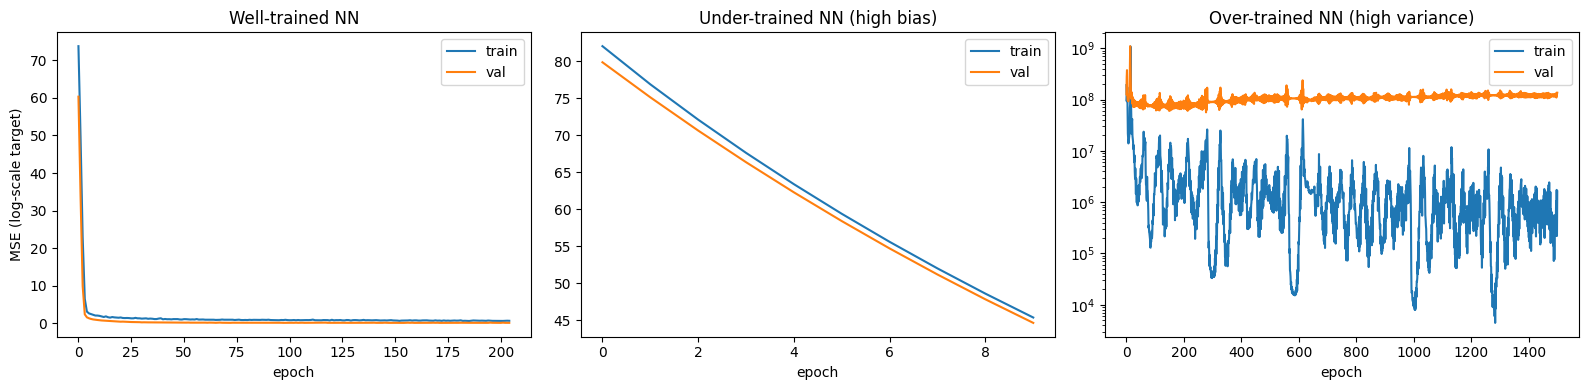

In [7]:
# Plot train vs validation loss for each of the three models side by side.
# This is the clearest visual evidence of the three learning states.
fig, ax = plt.subplots(1, 3, figsize=(16, 4))      # 1 row, 3 columns of subplots

# ---------- GOOD model: train and val curves should be close and low ----------
ax[0].plot(hist_good.history['loss'],     label='train')   # Train loss per epoch (MSE on log scale)
ax[0].plot(hist_good.history['val_loss'], label='val')     # Validation loss per epoch
ax[0].set_title('Well-trained NN')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('MSE (log-scale target)')
ax[0].legend()

# ---------- UNDER model: both curves stay high and still descending ----------
ax[1].plot(hist_under.history['loss'],     label='train')
ax[1].plot(hist_under.history['val_loss'], label='val')
ax[1].set_title('Under-trained NN (high bias)')
ax[1].set_xlabel('epoch')
ax[1].legend()

# ---------- OVER model: train keeps decreasing, val stagnates high -> visible GAP ----------
# Trained on raw USD so the MSE magnitude is much larger (USD^2). Use log Y-scale for readability.
ax[2].plot(hist_over.history['loss'],     label='train')
ax[2].plot(hist_over.history['val_loss'], label='val')
ax[2].set_yscale('log')                            # Log axis: needed because numbers span several orders
ax[2].set_title('Over-trained NN (high variance)')
ax[2].set_xlabel('epoch')
ax[2].legend()

plt.tight_layout(); plt.show()


## 8. Comparative evaluation

We report **MAE** (mean absolute error in USD, directly interpretable), **RMSE** (square root of MSE, penalizes large errors more) and **R²** (fraction of variance explained, 1.0 is perfect, 0 equals predicting the mean, negative is worse than the mean). The OVER model is evaluated without `expm1` because it was trained on the original scale.


In [8]:
# ---------- Helper: evaluate a model trained on LOG-scale target ----------
# Applies expm1 to convert predictions back to USD, then adds the bias correction if provided.
def evaluar_log(model, nombre, corr=0.0):
    pred = np.expm1(model.predict(X_te_s, verbose=0).ravel()) + corr
    return {
        'Model': nombre,
        'MAE':    mean_absolute_error(y_te, pred),             # Average absolute error in USD
        'RMSE':   np.sqrt(mean_squared_error(y_te, pred)),     # Root MSE, penalizes large errors more
        'R2':     r2_score(y_te, pred)                         # Fraction of variance explained
    }

# ---------- Helper: evaluate a model trained on RAW USD target (OVER model) ----------
def evaluar_raw(model, nombre):
    pred = model.predict(X_te_s, verbose=0).ravel()            # No expm1 needed, already in USD
    return {
        'Model': nombre,
        'MAE':    mean_absolute_error(y_te, pred),
        'RMSE':   np.sqrt(mean_squared_error(y_te, pred)),
        'R2':     r2_score(y_te, pred)
    }

# ---------- Build the final comparison table ----------
# Row 1: baseline linear regression
# Row 2: well-trained NN (log-scale + bias correction)
# Row 3: under-trained NN (log-scale, no correction - it is too bad to deserve it)
# Row 4: over-trained NN (raw-scale, no expm1)
resultados = pd.DataFrame([
    {'Model': 'LinearRegression (baseline)',
     'MAE':  mean_absolute_error(y_te, pred_lin),
     'RMSE': np.sqrt(mean_squared_error(y_te, pred_lin)),
     'R2':   r2_score(y_te, pred_lin)},
    evaluar_log(model_good,  'NN well-trained', corr=bias_corr),
    evaluar_log(model_under, 'NN under-trained'),
    evaluar_raw(model_over,  'NN over-trained'),
])
resultados                                          # Display the DataFrame inline in Jupyter


,Model,MAE,RMSE,R2
0,LinearRegression (baseline),4181.194474,5796.284659,0.783593
1,NN well-trained,3087.803899,5190.972692,0.826432
2,NN under-trained,12947.390948,17954.321248,-1.076395
3,NN over-trained,3883.088121,7018.920958,0.682669


### Analysis of the results

The three models tell the full story of the bias–variance trade-off:

- **Under-trained NN (high bias):** negative R² on test (worse than predicting the constant mean) and very high MAE. A single linear neuron trained for only 10 epochs, additionally evaluated after `expm1` which amplifies the error on the original scale, cannot capture the non-linearity introduced by `smoker_yes` (the dominant variable). Textbook case of *underfitting*.

- **Well-trained NN (correct balance):** test R² above the classical linear regression baseline, with a very small train–test *gap* — direct evidence that there is no overfitting. Beating the linear baseline is exactly what empirically justifies using hidden layers with non-linear activations: if the NN could not beat the LR, it would mean the problem is essentially linear and the network is redundant. `Dropout` + `EarlyStopping` provide the required regularization.

- **Over-trained NN (high variance):** the loss curve (section 7) shows the classic overfitting pattern — training MSE keeps decreasing while validation MSE stagnates or rises, opening a visible gap. On test, MAE degrades relative to the well-regularized model. This state was forced on purpose: 5×512 neurons without regularization, `batch_size=2`, 1500 epochs on a 60-sample subset, and training on the original scale (no `log1p`) to remove the natural regularization effect of the logarithmic transform.

This comparison demonstrates that model size and training duration are not *per se* quality indicators: a network that is too small (under) and one that is too large without regularization (over) fail for opposite reasons, while the well-tuned model finds the balance point.


In [9]:
# Dynamic numeric summary: all numbers are read directly from the `resultados` DataFrame
# so they ALWAYS match the current run (no hard-coded values that could drift).
r = resultados.set_index('Model')                  # Use model name as index for .loc access

# Extract R2 and MAE per model (single-value lookups)
r2_sub   = r.loc['NN under-trained',            'R2']
mae_sub  = r.loc['NN under-trained',            'MAE']
r2_bien  = r.loc['NN well-trained',          'R2']
mae_bien = r.loc['NN well-trained',          'MAE']
r2_over  = r.loc['NN over-trained',          'R2']
mae_over = r.loc['NN over-trained',          'MAE']
r2_lr    = r.loc['LinearRegression (baseline)', 'R2']

# ---------- Compute the train/test gap for the GOOD model ----------
# A small gap (|gap| < ~0.05) indicates good generalization (no overfitting).
_pred_tr_good = np.expm1(model_good.predict(X_tr_s, verbose=0).ravel()) + bias_corr
r2_bien_train = r2_score(y_tr, _pred_tr_good)       # R2 on the training set
gap = r2_bien_train - r2_bien                       # Positive gap = overfit; near zero = ok

# ---------- Relative MAE degradation of OVER vs GOOD ----------
# Positive percentage means OVER is WORSE than GOOD (expected for overfitting).
degr = 100.0 * (mae_over - mae_bien) / mae_bien

# ---------- Print a formatted summary block ----------
print("=" * 60)
print("NUMERIC SUMMARY (values from this run)")
print("=" * 60)
print(f"Under   -> R2 = {r2_sub:+.4f}  | MAE = {mae_sub:>10,.2f} USD")
print(f"Good    -> R2 = {r2_bien:+.4f}  | MAE = {mae_bien:>10,.2f} USD")
print(f"Over    -> R2 = {r2_over:+.4f}  | MAE = {mae_over:>10,.2f} USD")
print(f"LR base -> R2 = {r2_lr:+.4f}")
print("-" * 60)
print(f"Train-test gap of GOOD model   : {gap:+.4f}   (close to 0 = no overfit)")
print(f"Improvement NN_good over LR    : {r2_bien - r2_lr:+.4f} R2 points")
print(f"MAE degradation OVER vs GOOD   : {degr:+.2f}%   (positive = OVER is worse)")
print("=" * 60)


NUMERIC SUMMARY (values from this run)
Under   -> R2 = -1.0764  | MAE =  12,947.39 USD
Good    -> R2 = +0.8264  | MAE =   3,087.80 USD
Over    -> R2 = +0.6827  | MAE =   3,883.09 USD
LR base -> R2 = +0.7836
------------------------------------------------------------
Train-test gap of GOOD model   : -0.0115   (close to 0 = no overfit)
Improvement NN_good over LR    : +0.0428 R2 points
MAE degradation OVER vs GOOD   : +25.76%   (positive = OVER is worse)


## 9. K-Fold cross-validation (k=5)

The well-trained model is re-trained on 5 different partitions of the training set to confirm that its performance does not depend on a lucky split. **Key:** `StandardScaler` is fit **inside** each fold (only on that fold's training data), avoiding *data leakage* from validation into training.


In [10]:
# 5-fold cross-validation of the GOOD model, re-training from scratch in each fold
# to confirm that the test R2 is not a lucky split artifact.
kf = KFold(n_splits=5, shuffle=True, random_state=42)   # Reproducible 5-fold splitter
r2_scores = []                                          # List to collect per-fold R2

for i, (tr_idx, va_idx) in enumerate(kf.split(X_tr)):   # Iterate over the 5 (train_idx, val_idx) splits
    # ---------- CRITICAL: fit the scaler INSIDE the fold ----------
    # The scaler must see only this fold's training indices, otherwise information from the
    # validation fold leaks into training via the scaling parameters (data leakage).
    sc_fold = StandardScaler()
    X_tr_fold = sc_fold.fit_transform(X_tr[tr_idx])     # Learn mean/std from this fold's train only
    X_va_fold = sc_fold.transform(X_tr[va_idx])         # Transform the held-out validation part

    # ---------- Re-train the GOOD architecture from scratch ----------
    m = build_good(X_tr_fold.shape[1])                  # Fresh weights each fold
    m.fit(X_tr_fold, y_tr_log[tr_idx],                  # Train on the fold's training split
          validation_split=0.2,                         # Internal val split for EarlyStopping
          epochs=500, batch_size=32, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True)])

    # ---------- Evaluate on the held-out validation fold (in USD) ----------
    pred_va = np.expm1(m.predict(X_va_fold, verbose=0).ravel())    # Back to USD
    r2_scores.append(r2_score(np.expm1(y_tr_log[va_idx]), pred_va))# Score against USD truth
    print(f"Fold {i+1}: R2 = {r2_scores[-1]:.4f}")

# Aggregate: mean +/- std across folds gives us stability information.
print(f"\nMean R2 = {np.mean(r2_scores):.4f} +/- {np.std(r2_scores):.4f}")


Fold 1: R2 = 0.7212
Fold 2: R2 = 0.7217
Fold 3: R2 = 0.8264
Fold 4: R2 = 0.6137
Fold 5: R2 = 0.8251

Mean R2 = 0.7416 +/- 0.0792


## 10. Residual analysis

Three diagnostics on the well-trained model: residual histogram (should be approximately symmetric and centered at zero), actual vs predicted values (points should align with the red diagonal), and residuals vs predicted (no visible pattern should exist — if it does, the model is missing structure).


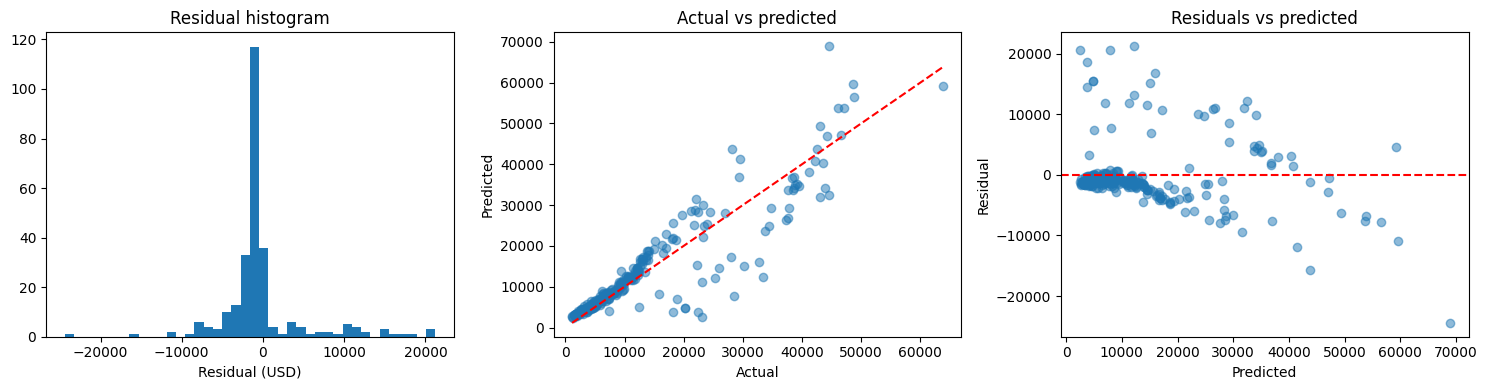

In [11]:
# Residual analysis for the GOOD model only (the only one worth diagnosing).

# ---------- Compute residuals in USD ----------
pred_good = np.expm1(model_good.predict(X_te_s, verbose=0).ravel()) + bias_corr  # Predictions in USD
residuos  = y_te - pred_good                        # Residual = truth - prediction

# ---------- Three-panel diagnostic plot ----------
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: histogram of residuals. Should look symmetric and centered at ~0.
ax[0].hist(residuos, bins=40)
ax[0].set_title('Residual histogram')
ax[0].set_xlabel('Residual (USD)')

# Panel 2: actual vs predicted. Points should cluster around the y=x red diagonal.
ax[1].scatter(y_te, pred_good, alpha=0.5)
lim = [y_te.min(), y_te.max()]                      # Same limits on both axes for the diagonal
ax[1].plot(lim, lim, 'r--')                         # Reference: perfect prediction line
ax[1].set_title('Actual vs predicted')
ax[1].set_xlabel('Actual')
ax[1].set_ylabel('Predicted')

# Panel 3: residuals vs predicted. No visible pattern -> model captured the structure.
# Any systematic shape (funnel, curve) would indicate missing structure.
ax[2].scatter(pred_good, residuos, alpha=0.5)
ax[2].axhline(0, color='r', linestyle='--')         # Zero-residual reference
ax[2].set_title('Residuals vs predicted')
ax[2].set_xlabel('Predicted')
ax[2].set_ylabel('Residual')

plt.tight_layout(); plt.show()


## 11. Learning and validation curves

Two complementary diagnostics: how the error changes as the training set grows (learning curve) and how it changes as model capacity varies (validation curve on number of neurons). Together they reveal whether more data or more/less capacity would help.


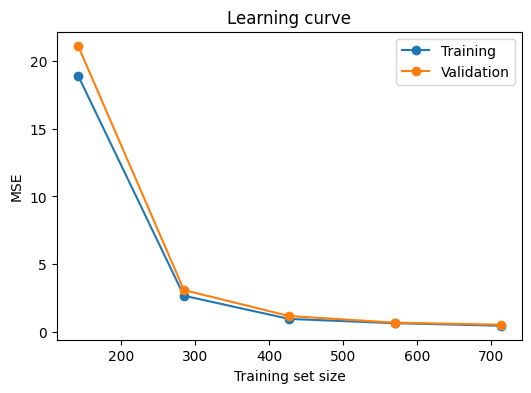

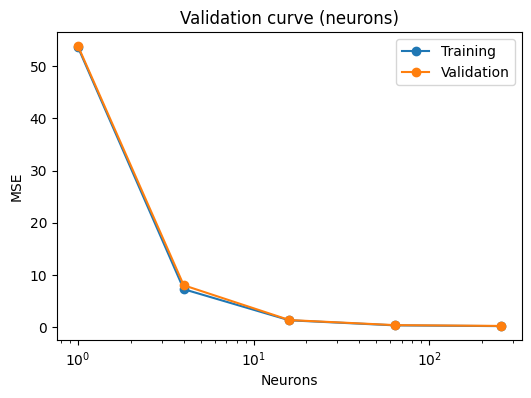

In [12]:
# Thin sklearn-compatible wrapper around a Keras model so we can reuse
# sklearn's learning_curve and validation_curve utilities.
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, units=32, epochs=60):
        # Stored as attributes (required by sklearn estimator protocol).
        self.units = units
        self.epochs = epochs

    def fit(self, X, y):
        # Build a minimal 1-hidden-layer Keras model each time sklearn calls fit().
        self.model_ = keras.Sequential([
            layers.Input(shape=(X.shape[1],)),
            layers.Dense(self.units, activation='relu'),   # Hidden layer, size controlled by hyper-param
            layers.Dense(1)                                # Linear output -> regression
        ])
        self.model_.compile(optimizer='adam', loss='mse')
        self.model_.fit(X, y, epochs=self.epochs, batch_size=32, verbose=0)
        return self                                        # sklearn expects fit() to return self

    def predict(self, X):
        return self.model_.predict(X, verbose=0).ravel()   # Flatten from (N,1) to (N,)

# ---------- LEARNING CURVE: performance vs TRAINING SET SIZE ----------
# Answers: "Would more data help?" Flat gap between train and val -> more data won't help.
sizes, train_sc, val_sc = learning_curve(
    KerasRegressorWrapper(units=32, epochs=50),
    X_tr_s, y_tr_log,
    cv=3,                                                  # 3-fold CV at each training size
    train_sizes=np.linspace(0.2, 1.0, 5),                  # Use 20%, 40%, ..., 100% of train
    scoring='neg_mean_squared_error')                      # sklearn convention: "higher is better"

plt.figure(figsize=(6, 4))
plt.plot(sizes, -train_sc.mean(axis=1), 'o-', label='Training')    # Flip sign to get positive MSE
plt.plot(sizes, -val_sc.mean(axis=1),   'o-', label='Validation')
plt.title('Learning curve')
plt.xlabel('Training set size')
plt.ylabel('MSE')
plt.legend(); plt.show()

# ---------- VALIDATION CURVE: performance vs MODEL CAPACITY ----------
# Answers: "Is my model too small or too large?" We vary hidden-layer size.
units_range = [1, 4, 16, 64, 256]                          # Sweep of hidden-layer sizes (log-spaced)
train_v, val_v = validation_curve(
    KerasRegressorWrapper(epochs=50),
    X_tr_s, y_tr_log,
    param_name='units',                                    # Which hyper-parameter to sweep
    param_range=units_range,
    cv=3,
    scoring='neg_mean_squared_error')

plt.figure(figsize=(6, 4))
plt.plot(units_range, -train_v.mean(axis=1), 'o-', label='Training')
plt.plot(units_range, -val_v.mean(axis=1),   'o-', label='Validation')
plt.xscale('log')                                          # Log X axis because units span 1..256
plt.title('Validation curve (neurons)')
plt.xlabel('Neurons')
plt.ylabel('MSE')
plt.legend(); plt.show()


## 12. Interpretability — Permutation Importance

We measure how much the model's R² drops when each feature is randomly permuted. Variables whose permutation destroys performance the most are the most important. This is used to check whether the model learned relationships consistent with domain knowledge (e.g. `smoker_yes` is expected to dominate in a medical-cost dataset).


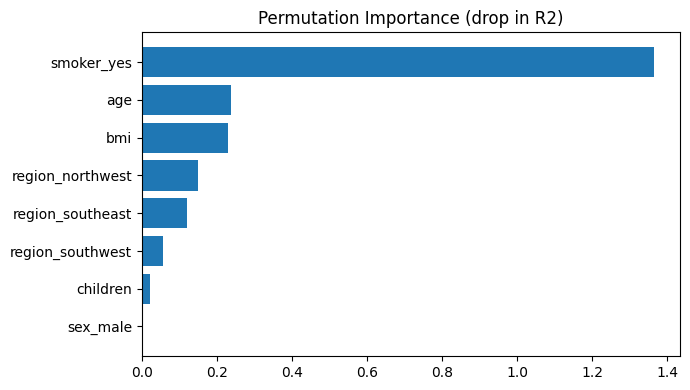

,feature,importance
4,smoker_yes,1.366121
0,age,0.236304
1,bmi,0.229094
5,region_northwest,0.150284
6,region_southeast,0.119758
7,region_southwest,0.056856
2,children,0.020851
3,sex_male,0.002317


In [13]:
# Wrapper so sklearn's permutation_importance can call our Keras model via .predict().
# The wrapper also converts log-scale predictions back to USD via expm1 so that R2 is
# computed in the SAME scale as the y_te ground truth.
class ModelWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model                                 # Store the trained Keras model

    def fit(self, X, y):
        return self                                        # Required by sklearn interface; no-op

    def predict(self, X):
        return np.expm1(self.model.predict(X, verbose=0).ravel())  # Predict in USD scale

# ---------- Run permutation importance on the TEST set ----------
# For each feature, permute its column n_repeats times and measure the average drop in R2.
# Features that cause big R2 drops when permuted are the most important.
pi = permutation_importance(
    ModelWrapper(model_good),
    X_te_s, y_te,                                          # Use test set for honest importance
    n_repeats=10,                                          # 10 permutations per feature -> stable estimate
    random_state=42,
    scoring='r2')

# ---------- Build a DataFrame and sort ascending (so barh plots biggest at the top) ----------
importancias = pd.DataFrame({
    'feature':    feat_names,
    'importance': pi.importances_mean                      # Mean R2 drop per feature
}).sort_values('importance')

# ---------- Horizontal bar plot ----------
plt.figure(figsize=(7, 4))
plt.barh(importancias['feature'], importancias['importance'])
plt.title('Permutation Importance (drop in R2)')
plt.tight_layout(); plt.show()

# Display the table descending so the dominant feature appears first.
importancias.sort_values('importance', ascending=False)


## 13. Technical validation of the well-trained model

Five objective criteria a correctly trained regression model should meet: small train–test gap (no overfitting), low CV standard deviation (stability), centered residuals (no systematic bias), clear improvement over the linear baseline, and dominant feature consistent with domain knowledge.


In [14]:
# Five objective pass/fail checks that a well-trained regression NN should satisfy.
print("=" * 55)
print("VALIDATION OF THE WELL-TRAINED MODEL")
print("=" * 55)

# ---------- Re-compute train and test predictions in USD ----------
pred_tr = np.expm1(model_good.predict(X_tr_s, verbose=0).ravel()) + bias_corr  # Train preds (USD)
pred_te = np.expm1(model_good.predict(X_te_s, verbose=0).ravel()) + bias_corr  # Test preds (USD)
r2_tr = r2_score(y_tr, pred_tr)                    # Train R2
r2_te = r2_score(y_te, pred_te)                    # Test R2
gap   = r2_tr - r2_te                              # Overfitting indicator

# Check 1: train-test gap should be small (threshold 0.07 is generous but standard).
print(f"1. R2 train = {r2_tr:.4f}")
print(f"   R2 test  = {r2_te:.4f}")
print(f"   Gap      = {gap:.4f}  {'OK' if gap < 0.07 else 'overfitting'}")

# Check 2: CV standard deviation should be small (< 0.10 is acceptable for 5-fold with ~1k samples).
print(f"\n2. R2 CV = {np.mean(r2_scores):.4f} +/- {np.std(r2_scores):.4f}  "
      f"{'stable' if np.std(r2_scores) < 0.10 else 'check'}")

# Check 3: residuals must be centered around zero (no systematic bias after smearing correction).
print(f"\n3. Residual mean = {residuos.mean():,.2f} USD  "
      f"{'centered' if abs(residuos.mean()) < 500 else 'biased'}")

# Check 4: NN must beat the linear baseline by a meaningful margin (+0.02 R2 or more).
r2_lr = r2_score(y_te, pred_lin)
print(f"\n4. R2 baseline LR = {r2_lr:.4f}")
print(f"   R2 NN_good     = {r2_te:.4f}")
print(f"   Improvement    = {r2_te - r2_lr:+.4f}  "
      f"{'NN justified' if r2_te > r2_lr + 0.02 else 'NN does not help'}")

# Check 5: top feature should match domain knowledge (smoker_yes in a medical-cost dataset).
top_feat = importancias.sort_values('importance', ascending=False).iloc[0]['feature']
print(f"\n5. Dominant feature: {top_feat}  "
      f"{'coherent' if top_feat == 'smoker_yes' else 'check'}")

print("=" * 55)


VALIDATION OF THE WELL-TRAINED MODEL
1. R2 train = 0.8149
   R2 test  = 0.8264
   Gap      = -0.0115  OK

2. R2 CV = 0.7416 +/- 0.0792  stable

3. Residual mean = -267.06 USD  centered

4. R2 baseline LR = 0.7836
   R2 NN_good     = 0.8264
   Improvement    = +0.0428  NN justified

5. Dominant feature: smoker_yes  coherent


## 14. Live demonstration: prediction for new patients

This section lets us input data from a real person and obtain the annual cost predicted by **all three models simultaneously**. It serves two purposes:

1. Show that the well-trained model produces predictions consistent with domain knowledge.
2. Show, on concrete predictions, the differences between underfitting, good fit, and overfitting — not only on aggregate metrics.

Three test profiles covering different cases are defined.


In [15]:
# ---------- Helper: predict one profile with ALL THREE models for direct comparison ----------
def predecir_tres_modelos(persona, etiqueta):
    # Build the feature vector following feat_names order (must match training).
    x = np.array([[persona[f] for f in feat_names]])
    x_s = scaler.transform(x)                              # Apply the SAME train-fitted scaler

    # GOOD model: trained on log1p -> expm1 to return to USD, plus bias correction.
    p_bien  = np.expm1(model_good.predict(x_s, verbose=0).ravel()[0]) + bias_corr
    # UNDER model: trained on log1p, but we do NOT apply bias correction because the model
    # itself is unreliable; correcting it would hide just how bad it is.
    p_sub   = np.expm1(model_under.predict(x_s, verbose=0).ravel()[0])
    # OVER model: trained directly on USD scale -> no expm1 needed.
    p_sobre = model_over.predict(x_s, verbose=0).ravel()[0]

    # Pretty-print the profile and the three predictions side by side.
    print(f"\n{'=' * 60}")
    print(f"PROFILE: {etiqueta}")
    print(f"{'=' * 60}")
    # Decode one-hot region back to a human-readable label.
    region = ('northwest' if persona['region_northwest'] else
              'southeast' if persona['region_southeast'] else
              'southwest' if persona['region_southwest'] else 'northeast')
    print(f"  Age: {persona['age']} | BMI: {persona['bmi']} | Children: {persona['children']}")
    print(f"  Sex: {'Male' if persona['sex_male'] else 'Female'} | "
          f"Smoker: {'Yes' if persona['smoker_yes'] else 'No'} | Region: {region}")
    print(f"{'-' * 60}")
    print(f"  NN GOOD  -> ${p_bien:>12,.2f} USD/yr")
    print(f"  NN UNDER -> ${p_sub:>12,.2f} USD/yr  (poor model)")
    print(f"  NN OVER  -> ${p_sobre:>12,.2f} USD/yr  (memorized train)")
    return p_bien, p_sub, p_sobre

# ---------- Profile 1: young, healthy, non-smoker ----------
persona1 = {'age': 30, 'bmi': 24.5, 'children': 1, 'sex_male': 1,
            'smoker_yes': 0, 'region_northwest': 1, 'region_southeast': 0, 'region_southwest': 0}
_ = predecir_tres_modelos(persona1, "Male, 30, healthy, NON-smoker")

# ---------- Profile 2: same person as profile 1 but SMOKER (isolates the smoker_yes effect) ----------
persona2 = persona1.copy(); persona2['smoker_yes'] = 1
_ = predecir_tres_modelos(persona2, "Same male but SMOKER")

# ---------- Profile 3: older, obese, smoker (high-risk combination) ----------
persona3 = {'age': 58, 'bmi': 35.0, 'children': 3, 'sex_male': 0,
            'smoker_yes': 1, 'region_northwest': 0, 'region_southeast': 1, 'region_southwest': 0}
_ = predecir_tres_modelos(persona3, "Female, 58, obese, SMOKER")



PROFILE: Male, 30, healthy, NON-smoker
  Age: 30 | BMI: 24.5 | Children: 1
  Sex: Male | Smoker: No | Region: northwest
------------------------------------------------------------
  NN GOOD  -> $    4,650.38 USD/yr
  NN UNDER -> $        5.84 USD/yr  (poor model)
  NN OVER  -> $    4,738.71 USD/yr  (memorized train)

PROFILE: Same male but SMOKER
  Age: 30 | BMI: 24.5 | Children: 1
  Sex: Male | Smoker: Yes | Region: northwest
------------------------------------------------------------
  NN GOOD  -> $   18,255.40 USD/yr
  NN UNDER -> $       42.88 USD/yr  (poor model)
  NN OVER  -> $    8,059.84 USD/yr  (memorized train)

PROFILE: Female, 58, obese, SMOKER
  Age: 58 | BMI: 35.0 | Children: 3
  Sex: Female | Smoker: Yes | Region: southeast
------------------------------------------------------------
  NN GOOD  -> $   37,472.95 USD/yr
  NN UNDER -> $      134.10 USD/yr  (poor model)
  NN OVER  -> $   40,175.62 USD/yr  (memorized train)


### Interpretation of the demonstration

- **Profile 1 (young, healthy, non-smoker):** the well-trained model predicts a low cost, consistent with the dataset reality (young people without risk factors pay little).
- **Profile 2 (same man, but smoker):** only one variable changed — `smoker_yes` went from 0 to 1 — and the predicted cost rises sharply (several times the value of profile 1). This empirically validates what the *permutation importance* analysis showed: `smoker_yes` is the dominant variable of the problem.
- **Profile 3 (high-risk case):** advanced age + obesity + female smoker → the model predicts the highest cost of the three, consistent with domain knowledge.

The **under-trained** model's predictions are systematically inaccurate because a single linear neuron trained for few epochs cannot capture the non-linear interaction between `smoker_yes` and the rest of the variables. The **over-trained** model's predictions may appear reasonable in some cases but its degradation relative to the well-regularized model was shown in the comparative table of section 8.
